In [19]:
import numpy as np
import pandas as pd
import re
from dataclasses import dataclass
import json
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
@dataclass
class LBLColumn:
    name: str
    column_number: int
    unit: str
    data_type: str
    start_byte: int
    bytes: int
    description: str

In [ ]:
# Col parser takes in a .LBL file and returns a list containing column metadata
def col_parser(filename):
    start_re = re.compile(r"^\s*OBJECT\s*=\s*COLUMN\s*$", re.IGNORECASE)
    end_re   = re.compile(r"^\s*END_OBJECT\s*=\s*COLUMN\s*$", re.IGNORECASE)
    
    # key = value lines
    kv_re = re.compile(r"^\s*([A-Z_]+)\s*=\s*(.*)$")

    columns = []
    current = None
    collecting_description = False
    desc_lines = []

    with open(filename) as lbl:
        for raw in lbl:
            line = raw.rstrip("\n")

            # Start of a column block
            if start_re.match(line):
                current = {}
                collecting_description = False
                desc_lines = []
                continue

            # End of a column block
            if current is not None and end_re.match(line):
                # finalize description
                if desc_lines:
                    current["DESCRIPTION"] = " ".join(d.strip() for d in desc_lines).strip()
                else:
                    current.setdefault("DESCRIPTION", "")

                columns.append(
                    LBLColumn(
                        name=current.get("NAME", ""),
                        column_number=int(current.get("COLUMN_NUMBER", "0")),
                        unit=current.get("UNIT", ""),
                        data_type=current.get("DATA_TYPE", ""),
                        start_byte=int(current.get("START_BYTE", "0")),
                        bytes=int(current.get("BYTES", "0")),
                        description=current.get("DESCRIPTION", "")
                    )
                )
                current = None
                continue

            # Inside a column block
            if current is not None:
                # Detect start/end of multi-line DESCRIPTION
                if 'DESCRIPTION' in current and collecting_description:
                    # Continue until closing quote
                    if line.strip().endswith('"'):
                        desc_lines.append(line.strip().rstrip('"'))
                        collecting_description = False
                    else:
                        desc_lines.append(line.strip())
                    continue

                # Parse key=value
                m = kv_re.match(line)
                if not m:
                    continue

                key, value = m.group(1), m.group(2).strip()

                # Detect single-line or start multi-line DESCRIPTION
                if key == "DESCRIPTION":
                    if value.startswith('"') and value.endswith('"') and len(value) > 1:
                        # single line
                        current[key] = value.strip('"')
                    else:
                        # start multi-line description
                        collecting_description = True
                        first = value.lstrip('"')
                        if first:
                            desc_lines.append(first)
                    continue

                current[key] = value.strip('"')

    return columns


In [ ]:
columns = col_parser("data/VOYAGER/HG_48S.LBL")

print(columns)

[LBLColumn(name='Time', column_number=1, unit='N/A', data_type='TIME', start_byte=1, bytes=23, description=''), LBLColumn(name='Spacecraft Clock', column_number=2, unit='N/A', data_type='CHARACTER', start_byte=25, bytes=12, description=''), LBLColumn(name='MAG ID', column_number=3, unit='N/A', data_type='ASCII_INTEGER', start_byte=38, bytes=1, description=''), LBLColumn(name='Br', column_number=4, unit='nT', data_type='ASCII_REAL', start_byte=40, bytes=9, description=''), LBLColumn(name='Bt', column_number=5, unit='nT', data_type='ASCII_REAL', start_byte=50, bytes=9, description=''), LBLColumn(name='Bn', column_number=6, unit='nT', data_type='ASCII_REAL', start_byte=60, bytes=9, description=''), LBLColumn(name='Bmag', column_number=7, unit='nT', data_type='ASCII_REAL', start_byte=70, bytes=9, description=''), LBLColumn(name='Average Bmag', column_number=8, unit='nT', data_type='ASCII_REAL', start_byte=80, bytes=9, description=''), LBLColumn(name='Delta', column_number=9, unit='DEGREE',

In [ ]:
# tab_parse is the key function in this parsing api. It takes in the name of a 
# .lbl file, a .tab file, and a delimiter (defaulted to ','). It returns a dataframe
# containing the contents of the .tab file and a list containing column metadata
def tab_parse(lbl_file, tab_file, delim=','): 
    columns = col_parser(lbl_file)
    column_names = [c.name for c in columns]

    data = []

    # REGEX statements for detecting label and decorative lines 
    label = re.compile(r'^\s*\d+(?:\s+\d+)*\s*$')
    decor = re.compile(r'^[= ]+$')

    with open(tab_file) as tab: 
        for line in tab: 
            # skip decorative lines
            if (decor.match(line) or label.match(line)): 
                continue

            if (delim==' '): 
                fields = line.strip().split()
            else: 
                fields = line.strip().split(delim)

            data.append(fields)

    df = pd.DataFrame(data, columns=column_names)

    return df, columns

In [ ]:
# save takes in a dataframe and a columns list, a new file name, 
# and a mode (either csv_json or parquet) and saves the data and 
# metadata to the respective file type 
def save(dataframe, columns, name, mode='csv_json'): 
    if mode == 'csv_json': 
        dataframe.to_csv(name+'.csv', index=False)

        meta = [c.__dict__ for c in columns]
        with open(name + ".json", "w") as f:
            json.dump(meta, f, indent=2)

        return
    
    if mode == "parquet":
        table = pa.Table.from_pandas(dataframe)

        meta = table.schema.metadata or {}
        meta = dict(meta)
        meta["lbl_columns"] = json.dumps([c.__dict__ for c in columns]).encode()

        table = table.replace_schema_metadata(meta)
        pq.write_table(table, name + ".parquet")

        return
    
    raise ValueError("mode must be 'csv_json' or 'parquet'")

In [7]:
apollo_df, apollo_cols =  tab_parse("data/APOLLO/apollo12_sws_28s_19691119.lbl", "data/APOLLO/apollo12_sws_28s_19691119.tab", ' ')
voyager_df, voyager_cols = tab_parse("data/VOYAGER/HG_48S.LBL", "data/VOYAGER/HG_48S.TAB")

In [8]:
apollo_df.head()

,EPOCH,JULIAN_DATE,DENSITY,AP_RATIO,VEL,VTH,EAST,NORTH,FLAG,IA,...,IDISCP,GAIN,RMS,KUPA,CURA,CURB,CURC,CUR7,FACTD,XNOISE
0,1969-11-19T18:42:13,2440545.27932,1.8,-9.99,493,318,-99.9,-99.9,2622080,3,...,0,0,19.0,2,13.0,-999.9,2.0,3.0,2.60,6.7
1,1969-11-19T18:42:41,2440545.27964,0.8,-9.99,591,256,-99.9,-99.9,2622080,3,...,0,0,16.0,2,9.0,-999.9,-999.9,1.0,1.90,7.2
2,1969-11-19T18:43:09,2440545.27997,0.4,-9.99,734,145,-99.9,-99.9,2622080,3,...,0,0,17.0,2,10.0,-999.9,2.0,-999.9,1.30,7.1
3,1969-11-19T18:43:37,2440545.28029,0.6,-9.99,673,187,-99.9,-99.9,2622080,3,...,0,0,14.0,2,10.0,-999.9,-999.9,-999.9,1.46,6.7
4,1969-11-19T18:44:05,2440545.28061,1.0,-9.99,591,230,-99.9,-99.9,2622080,3,...,0,0,13.0,2,13.0,-999.9,2.0,1.0,1.76,6.7


In [9]:
print(apollo_cols)

[LBLColumn(name='EPOCH', column_number=1, unit='', data_type='TIME', start_byte=1, bytes=19, description='Universal Time'), LBLColumn(name='JULIAN_DATE', column_number=2, unit='', data_type='ASCII_REAL', start_byte=22, bytes=13, description='Julian date for the universal time in'), LBLColumn(name='DENSITY', column_number=3, unit='protons/cm**3', data_type='ASCII_REAL', start_byte=37, bytes=5, description='Proton Density'), LBLColumn(name='AP_RATIO', column_number=4, unit='', data_type='ASCII_REAL', start_byte=44, bytes=5, description='Alpha to Proton Ratio'), LBLColumn(name='VEL', column_number=5, unit='km/s', data_type='ASCII_INTEGER', start_byte=51, bytes=4, description='Proton Bulk Speed'), LBLColumn(name='VTH', column_number=6, unit='km/s', data_type='ASCII_INTEGER', start_byte=57, bytes=3, description='Proton Thermal Velocity'), LBLColumn(name='EAST', column_number=7, unit='deg', data_type='ASCII_REAL', start_byte=62, bytes=5, description='Proton Flow Angle toward East in Solar'),

In [16]:
save(apollo_df, apollo_cols, "apollo", "csv_json")
save(apollo_df, apollo_cols, "apollo", "parquet")
save(voyager_df, voyager_cols, "voyager", "csv_json")
save(voyager_df, voyager_cols, "voyager", "parquet")

In [ ]:
voyager_df.head()

,Time,Spacecraft Clock,MAG ID,Br,Bt,Bn,Bmag,Average Bmag,Delta,Lambda,RMS Br,RMS Bt,RMS Bn,NPTS,DFLAG
0,1979-02-26T00:00:35.897,16164:19:001,1,-0.630,0.968,0.015,1.155,1.156,0.759,123.065,0.014,0.025,0.046,5,""" """
1,1979-02-26T00:01:23.897,16164:20:001,1,-0.568,0.998,-0.076,1.151,1.153,-3.777,119.676,0.029,0.018,0.066,5,""" """
2,1979-02-26T00:02:11.897,16164:21:001,1,-0.598,0.983,-0.074,1.153,1.155,-3.654,121.300,0.057,0.018,0.040,5,""" """
3,1979-02-26T00:02:59.897,16164:22:001,1,-0.656,0.951,-0.076,1.158,1.160,-3.775,124.572,0.057,0.047,0.015,5,""" """
4,1979-02-26T00:03:47.897,16164:23:001,1,-0.630,0.980,-0.055,1.167,1.167,-2.681,122.732,0.019,0.018,0.015,5,""" """


In [10]:
print(voyager_cols)

[LBLColumn(name='Time', column_number=1, unit='N/A', data_type='TIME', start_byte=1, bytes=23, description=''), LBLColumn(name='Spacecraft Clock', column_number=2, unit='N/A', data_type='CHARACTER', start_byte=25, bytes=12, description=''), LBLColumn(name='MAG ID', column_number=3, unit='N/A', data_type='ASCII_INTEGER', start_byte=38, bytes=1, description=''), LBLColumn(name='Br', column_number=4, unit='nT', data_type='ASCII_REAL', start_byte=40, bytes=9, description=''), LBLColumn(name='Bt', column_number=5, unit='nT', data_type='ASCII_REAL', start_byte=50, bytes=9, description=''), LBLColumn(name='Bn', column_number=6, unit='nT', data_type='ASCII_REAL', start_byte=60, bytes=9, description=''), LBLColumn(name='Bmag', column_number=7, unit='nT', data_type='ASCII_REAL', start_byte=70, bytes=9, description=''), LBLColumn(name='Average Bmag', column_number=8, unit='nT', data_type='ASCII_REAL', start_byte=80, bytes=9, description=''), LBLColumn(name='Delta', column_number=9, unit='DEGREE',

In [10]:
summary_df = pd.read_csv("data/summary.csv")

In [11]:
summary_df.head()

,planet,mass_kg,volume_km3,density_kg/km3,gravity_m/s2,high_temp_c,low_temp_c,atmos_pressure_mbar,atmos_N,atmos_O,atmos_CO2,atmos_CH4,atmos_H
0,Mercury,3.290000e+23,6.080000e+10,5.430000e+12,3.7,449.0,-170.0,0.00,0.04,0.4200,0.03,0.0100,0.2200
1,Venus,4.890000e+24,9.280000e+11,5.260000e+12,8.9,470.0,465.0,100.00,0.03,0.0010,0.96,0.0010,0.0000
2,Earth,5.980000e+24,1.080000e+12,5.520000e+12,9.8,58.0,-89.0,100.00,0.78,0.2100,0.01,0.0050,0.0010
3,Mars,6.460000e+23,1.630000e+11,3.970000e+12,3.7,20.0,-125.0,0.01,0.03,0.0001,0.95,0.0001,0.0005
4,Jupiter,1.900000e+27,1.430000e+15,1.330000e+12,23.1,-110.0,-110.0,140.00,0.00,0.0000,0.00,0.0000,0.9000


In [16]:

# Load CSV
earth_adjusted_summary_df = summary_df

# Identify the Earth row
earth = earth_adjusted_summary_df[earth_adjusted_summary_df["planet"] == "Earth"].iloc[0]

for col in earth_adjusted_summary_df.columns[1:]:
    earth_adjusted_summary_df[col] = earth_adjusted_summary_df[col] / earth[col]


In [17]:
earth_adjusted_summary_df.head()

,planet,mass_kg,volume_km3,density_kg/km3,gravity_m/s2,high_temp_c,low_temp_c,atmos_pressure_mbar,atmos_N,atmos_O,atmos_CO2,atmos_CH4,atmos_H
0,Mercury,0.055017,0.056296,0.983696,0.377551,7.741379,1.910112,0.0000,0.051282,2.000000,3.0,2.00,220.0
1,Venus,0.817726,0.859259,0.952899,0.908163,8.103448,-5.224719,1.0000,0.038462,0.004762,96.0,0.20,0.0
2,Earth,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.0,1.00,1.0
3,Mars,0.108027,0.150926,0.719203,0.377551,0.344828,1.404494,0.0001,0.038462,0.000476,95.0,0.02,0.5
4,Jupiter,317.725753,1324.074074,0.240942,2.357143,-1.896552,1.235955,1.4000,0.000000,0.000000,0.0,0.00,900.0


In [ ]:
earth_adjusted_summary_df.to_csv("data/earth_adjusted_summary.csv", index=False)

In [18]:
import matplotlib.pyplot as plt

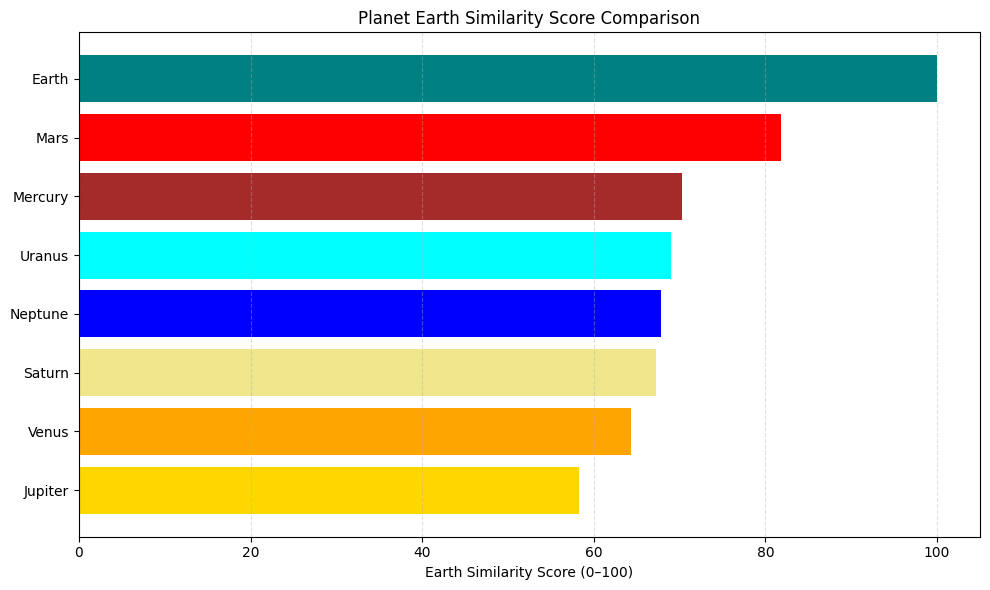

In [20]:
# Earth similarity values
similarity = {
    'Mercury': 70.23,
    'Venus': 64.34,
    'Earth': 100.0,
    'Mars': 81.77,
    'Jupiter': 58.22,
    'Saturn': 67.24,
    'Uranus': 68.97,
    'Neptune': 67.87
}

# Planet categories
category_colors = {
    'Mercury': 'brown', 
    'Venus': 'orange',
    'Earth': 'teal',
    'Mars': 'red',
    'Jupiter': 'gold',
    'Saturn': 'khaki',
    'Uranus': 'cyan',
    'Neptune': 'blue'
}

df = pd.DataFrame(list(similarity.items()), columns=['Planet', 'Similarity'])
df = df.sort_values(by='Similarity', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(df['Planet'], df['Similarity'],
                color=[category_colors[p] for p in df['Planet']])

plt.xlabel("Earth Similarity Score (0–100)")
plt.title("Planet Earth Similarity Score Comparison")
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


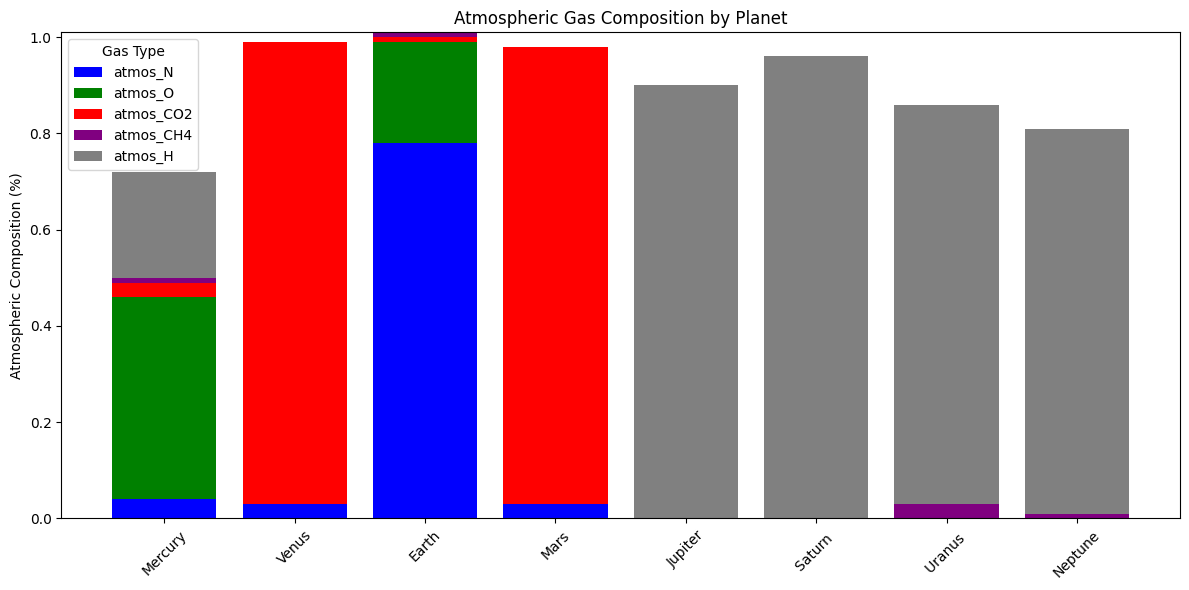

In [21]:
df = pd.read_csv("data/summary.csv")

gases = ["atmos_N", "atmos_O", "atmos_CO2", "atmos_CH4", "atmos_H"]
colors = ["blue", "green", "red", "purple", "gray"]

plt.figure(figsize=(12, 6))

bottom = [0] * len(df)

for gas, color in zip(gases, colors):
    plt.bar(df["planet"], df[gas], bottom=bottom, label=gas, color=color)
    bottom = bottom + df[gas]

plt.ylabel("Atmospheric Composition (%)")
plt.title("Atmospheric Gas Composition by Planet")
plt.legend(title="Gas Type")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


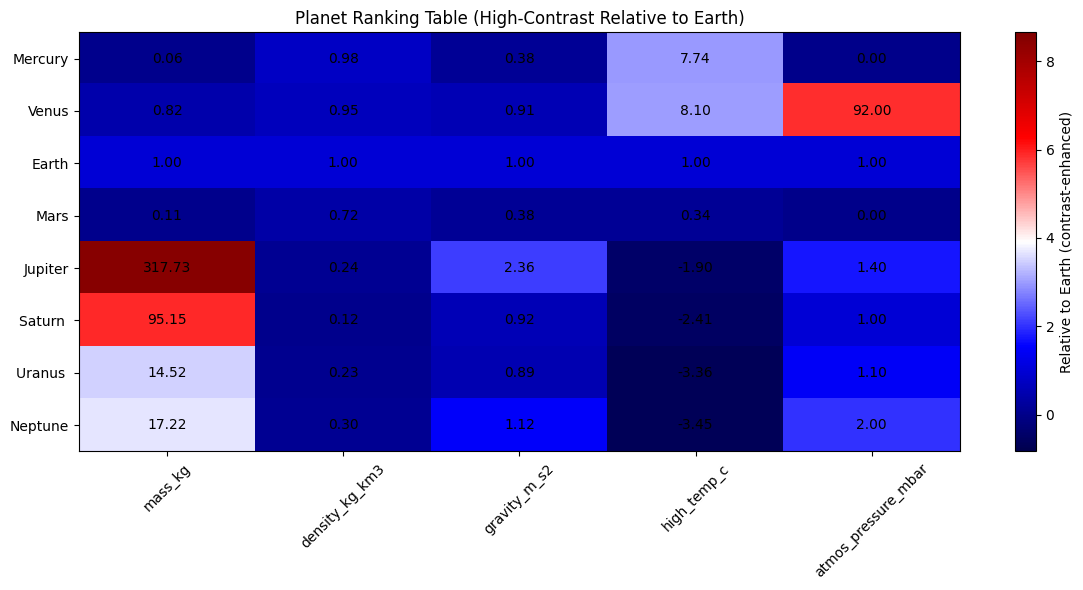

In [25]:
# Load CSV
df = pd.read_csv("data/summary.csv")

metrics = [
    "mass_kg",
    "density_kg_km3",
    "gravity_m_s2",
    "high_temp_c",
    "atmos_pressure_mbar"
]

# Normalize relative to Earth
earth = df[df["planet"] == "Earth"].iloc[0]
relative_df = df[["planet"]].copy()

for m in metrics:
    relative_df[m] = df[m] / earth[m]

relative_df = relative_df.set_index("planet")

# Increase contrast using gamma scaling
# gamma < 1 exaggerates differences
gamma = 0.35
contrast_df = relative_df.copy()
contrast_df = np.sign(contrast_df - 1) * (np.abs(contrast_df - 1) ** gamma) + 1

plt.figure(figsize=(12, 6))

# Wider scaling range to exaggerate contrast
vmin = contrast_df.min().min() - 0.15
vmax = contrast_df.max().max() + 0.15

ax = plt.imshow(
    contrast_df,
    cmap="seismic",     # more extreme high-contrast diverging colormap
    aspect="auto",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(ax, label="Relative to Earth (contrast-enhanced)")

plt.xticks(range(len(metrics)), metrics, rotation=45)
plt.yticks(range(len(contrast_df.index)), contrast_df.index)

plt.title("Planet Ranking Table (High-Contrast Relative to Earth)")

# Show more readable values: original normalized values, not gamma-warped
for i in range(len(relative_df.index)):
    for j in range(len(metrics)):
        value = relative_df.iloc[i, j]
        plt.text(
            j, i, f"{value:.2f}",
            ha="center", va="center",
            color="black"
        )

plt.tight_layout()
plt.show()
